In [4]:
# Import libraries
import os
# from os import listdir
# os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from processing_functions import csv_2_gdf
import plotly.express as px

### Import OSM data for Illinois

In [5]:
# this is road network extracted from the Open street map data
file_path = r"D:\Work\Box Sync\TRB 2024\Extracted_links\\" 
os.chdir(file_path)

In [6]:
# https://stackoverflow.com/questions/71907567/valueerror-geodataframe-does-not-support-multiple-columns-using-the-geometry-co
# Coordinate system of osm: http://download.geofabrik.de/osm-data-in-gis-formats-free.pdf
# must have a geometry column in csv
def csv_2_gdf(filename):
    df = pd.read_csv('illinois_link.csv', encoding='cp1252')
    gdf = gpd.GeoDataFrame(df.loc[:, [c for c in df.columns if c != "geometry"]], 
                           geometry=gpd.GeoSeries.from_wkt(df["geometry"]),
                           crs='EPSG:4326',)
    return gdf

In [7]:
# Reading and saving the links data as a dict
links = csv_2_gdf('illinois_link.csv')
links.shape

links.head()

state_streets_proj = links.to_crs('EPSG:9311')
state_streets_major = state_streets_proj[(state_streets_proj['link_type'] < 7) | (state_streets_proj['link_type'] == 15)]

state_streets_major.shape

state_streets_major.columns

print(state_streets_major['length'].sum())

state_streets_major.groupby(['link_type', 'link_type_name'])['length'].sum()

# state_streets_major[(state_streets_major['link_type_name'] == 'residential') | (state_streets_major['link_type_name'] == 'unclassified') ].plot()

499879852.2200003


link_type  link_type_name
1          motorway          9.774217e+06
2          trunk             2.695866e+06
3          primary           2.263968e+07
4          secondary         2.676424e+07
5          tertiary          4.610398e+07
6          residential       3.274180e+08
15         unclassified      6.448384e+07
Name: length, dtype: float64

<Axes: >

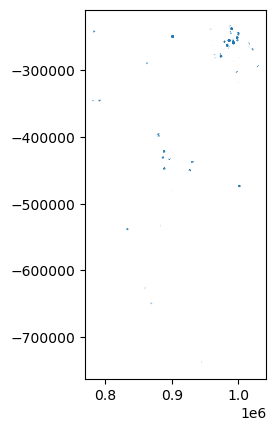

In [8]:
# state_streets_proj.groupby(['link_type', 'link_type_name'])['length'].sum()
state_streets_proj[state_streets_proj['link_type_name'] == 'living_street'].plot()

In [9]:
state_streets_major.groupby(['link_type', 'link_type_name'])['length'].sum()

link_type  link_type_name
1          motorway          9.774217e+06
2          trunk             2.695866e+06
3          primary           2.263968e+07
4          secondary         2.676424e+07
5          tertiary          4.610398e+07
6          residential       3.274180e+08
15         unclassified      6.448384e+07
Name: length, dtype: float64

In [10]:
state_streets_major['link_type_name'].unique()

array(['secondary', 'tertiary', 'residential', 'trunk', 'motorway',
       'primary', 'unclassified'], dtype=object)

### Reading OSM road length and find regression line

In [11]:

# Specify the folder containing CSV files
folder_path = 'D:\Work\Box Sync\TRB 2024\Streets_dfs'

# Get a list of all CSV files in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Initialize an empty DataFrame to store concatenated data
concatenated_df = pd.DataFrame()

# Loop through each CSV file and concatenate them
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path, dtype = {'GEOID': str})
    
    # Concatenate the DataFrame to the existing data
    concatenated_df = pd.concat([concatenated_df, df], ignore_index=True)

# Display the concatenated DataFrame
# print(concatenated_df)

In [12]:
df_out = concatenated_df.copy()

In [209]:
df_out.shape

(31554, 14)

In [14]:
df_out['total_length'] = df_out[['motorway_roads', 'trunk_roads', 'primary_roads', 'secondary_roads',
       'tertiary_roads', 'unclassified_roads', 'residential_roads']].sum(axis =1)

In [431]:
df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', 
                            index_col  = 0, dtype = {'GEOID': str})

df_attributes = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\df_attributes.csv', 
                            index_col  = 0, dtype = {'GEOID': str})

df_population = df_population.merge(df_attributes[['GEOID', 'city type', 'weighted_HU_density_sqmi', 'density_km2']], on = 'GEOID')



In [432]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
import math
import plotly.express as px



def find_scale_parameters(df, infra_col, pop_col):
    df.loc[:,'log_pop_col'] = np.log(df[pop_col])
    df.loc[:, 'log_infra_col'] = np.log(df[infra_col])

    fig = px.scatter(df, x='log_pop_col', y='log_infra_col', hover_data=['GEOID', 'NAMELSAD'],
                    width=800, height=800) 
    fig.show()
    # Check plot how the log-log plot looks?
    # ADD A QUESTION ASKING WHETHER A PLOT OR NOT???
    sns.regplot(x='log_pop_col', y='log_infra_col', data=df, 
                y_jitter=.03, ci =None, scatter_kws={"s": 1})
    x = df['log_pop_col']
    y = df['log_infra_col']

    #run anova model to find confidence intervals
    # Fit the regression model
    model = sm.ols("y ~ x", data={"y": y, "x": x}).fit()

    # Display regression summary
    print(model.summary())
    print(model.params)
    # Calculate confidence intervals using ANOVA
    anova_result = anova_lm(model)
    conf_int = model.conf_int(alpha=0.05, cols=None)

    # Display ANOVA results and confidence intervals
    print("\nConfidence Intervals: 'log(a)' and 'b' values---")
    print(conf_int)
    intercepts = [conf_int.iloc[0][0], conf_int.iloc[0][1]]
    beta = [conf_int.iloc[1][0], conf_int.iloc[1][1]]
    model_params = model.params
    return intercepts, beta, model_params


### df_combined

In [212]:
df_combined = df_out.merge(df_population[['GEOID', 'CensusPop_20', 'label','city type', 'State', 
                                          'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060']],
                          how = 'left')
'''
Source: 
Frantz, D., Schug, F., Wiedenhofer, D. et al. Unveiling patterns in human dominated landscapes through mapping the mass of US built structures. 
Nat Commun 14, 8014 (2023). https://doi.org/10.1038/s41467-023-43755-5
Supplementary Table 10
'''

df_combined['road_area'] = (df_combined['motorway_roads'] * 27.2 + df_combined['trunk_roads'] * 19.2 + df_combined['primary_roads'] *12.0 + df_combined['secondary_roads'] * 10.6 + 
                            df_combined['tertiary_roads'] * 9.8 + df_combined['unclassified_roads'] * 9.0 + df_combined['residential_roads'] * 9.0)

df_combined = df_combined[(df_combined['total_length'] != 0) & (df_combined['CensusPop_20'] != 0)]
df_combined_city = df_combined[df_combined['CensusPop_20'] != 0]
stocks_with_pop = df_combined_city[df_combined_city['city type'] == 'suburban']
# Replace NaN in the current trend column
stocks_with_pop.fillna({'label' : 'not enough data'}, inplace=True)
# stocks_with_pop.isna().sum()

# Set the threshold to the 90th percentile
threshold = stocks_with_pop['total_length'].quantile(0.9)
# Filter the DataFrame to include only points in the lower 90%
stocks_with_pop = stocks_with_pop[stocks_with_pop['total_length'] <= threshold]

C:\Users\uttar\AppData\Local\Temp\ipykernel_19988\1904259832.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [214]:
# find_scale_parameters(df_combined_city, infra_col= 'total_length', pop_col = 'CensusPop_20')

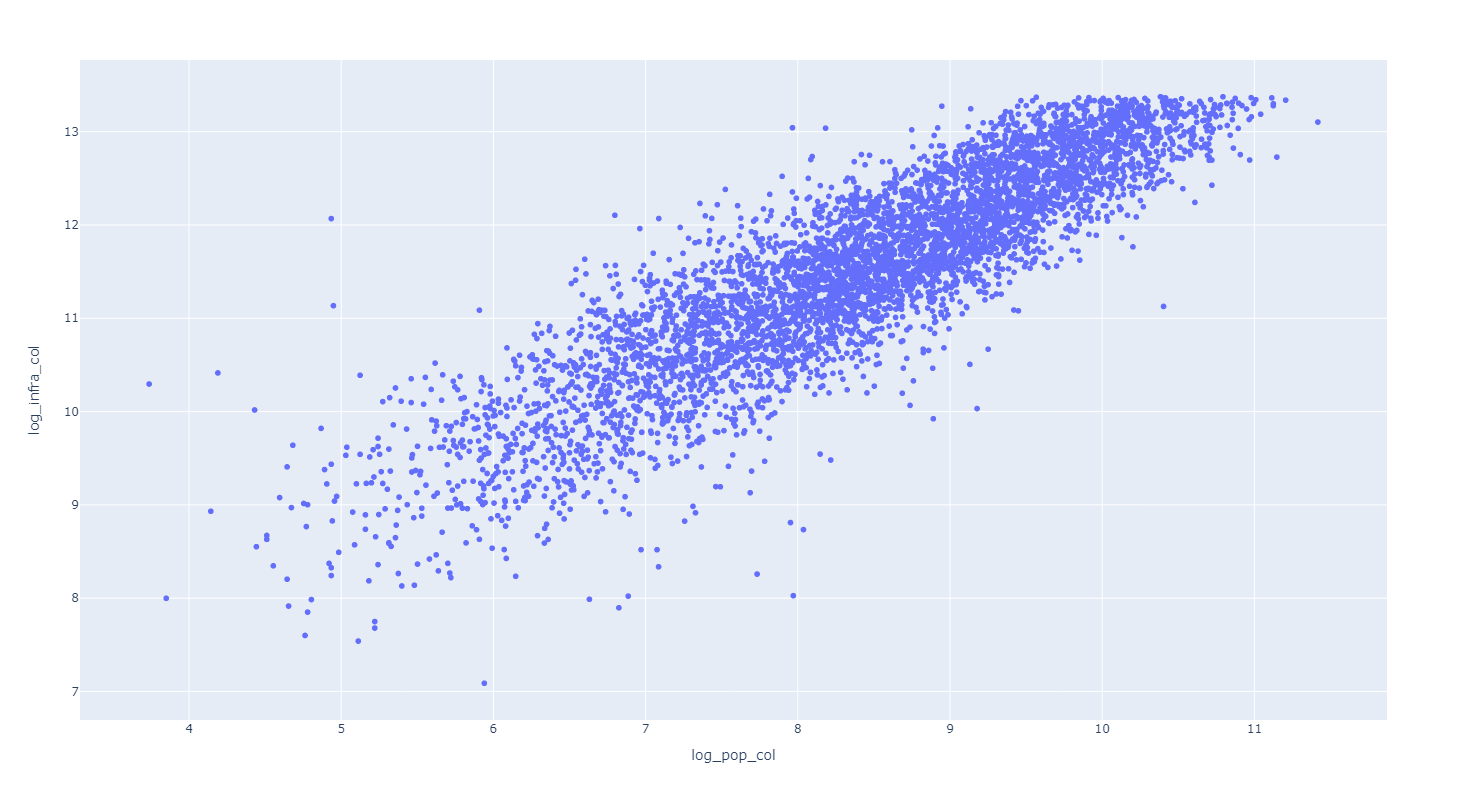

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                 2.014e+04
Date:                Wed, 21 Feb 2024   Prob (F-statistic):               0.00
Time:                        02:59:11   Log-Likelihood:                -3905.0
No. Observations:                5433   AIC:                             7814.
Df Residuals:                    5431   BIC:                             7827.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0643      0.046    109.940      0.0

,NAMELSAD,city type,total_length,additional_mass_building,added_mass_building,building_mass_reg,road_area,per_cap_mass,per_cap_mass_40,per_cap_mass_added,CensusPop_20,ssp22020,ssp22040
17794,Lindenhurst village,suburban,300700.22,-8479.199986,396143.762862,404622.962848,2786402.336,11.076330,10.750026,-0.311927,27148.0,27300.69645,27183.28453
13585,Hutchinson city,suburban,331108.66,-4721.317682,246459.031224,251180.348906,3216914.436,22.680229,22.151026,-0.320423,14599.0,14686.12222,14734.63761
6134,Libertyville village,suburban,311438.57,-4324.981776,322699.880784,327024.862561,2952941.150,15.133805,14.891860,-0.209717,20579.0,20702.51806,20622.91709
20602,Norwalk city,suburban,301099.31,-3319.316787,279911.596624,283230.913411,3071223.838,17.641159,17.415523,-0.194129,17068.0,17174.90011,17098.53822
18886,Smithtown CDP,suburban,445835.20,-3063.966649,384043.415669,387107.382318,4279242.652,17.395731,17.273790,-0.119534,25629.0,25772.41030,25632.54666
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19935,Dickinson city,suburban,584804.77,239007.222011,626694.910115,387687.688103,6337560.778,22.773658,17.341057,5.031048,25679.0,25869.12040,47506.44627
29035,Ashburn CDP,suburban,575692.90,258337.721915,868706.004245,610368.282330,6300849.940,12.420827,11.328353,3.508913,46349.0,46677.08458,73623.28714
28854,Leesburg town,suburban,529268.01,269625.045256,899144.122738,629519.077482,5787567.706,10.969285,10.526651,3.552727,48250.0,48592.33610,75892.42633
27399,The Colony city,suburban,525414.64,272109.372422,864022.871364,591913.498942,5202429.320,11.798056,11.084305,3.781884,44534.0,44851.18378,71950.74883


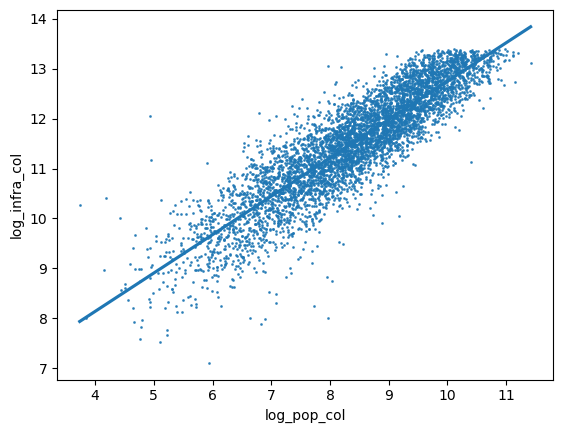

In [215]:
existing_stock_col = 'total_length' #'road_area'# 

x = find_scale_parameters(stocks_with_pop, infra_col= existing_stock_col, pop_col = 'CensusPop_20')
stocks_with_pop.loc[:,'building_mass_reg'] = np.exp(x[2].Intercept) * stocks_with_pop.loc[:, 'CensusPop_20']**x[2].x

# Set the range for the uniform distribution
log_a_lower = x[0][0]
log_a_upper= x[0][1]

beta_lower = x[1][0]
beta_upper= x[1][1]

# Create a uniform distribution
log_a_uniform = np.random.uniform(low=log_a_lower, high=log_a_upper, size=100000)
beta_uniform = np.random.uniform(low=beta_lower, high=beta_upper, size=100000)

# CHECK THE NUMEBR OF TRUE AND FALSE VALUES 
# stocks_with_pop['label'].str.contains('depopulating').value_counts().iloc[0]
stocks_with_pop.loc[:,'added_mass_building'] = np.nan

# Define a condition
condition = stocks_with_pop['ssp22040'] < stocks_with_pop['CensusPop_20'] #
# condition =  stocks_with_pop['label'].str.contains('depopulating')

# Fill the column based on the condition
stocks_with_pop.loc[condition, 'added_mass_building'] = 0
# stocks_with_pop.loc[~condition, 'added_mass_building'] = (np.random.choice(a_uniform, 
#                                                                           size=11776) * stocks_with_pop.loc[~condition, 'CensusPop_20']**(np.random.choice(beta_uniform,
#                                                                           size=11776))) #- stocks_with_pop.loc[~condition, 'building_mass_t']
size = condition.value_counts().iloc[0]
# Define a custom function to generate samples
def sample_function(p):
    return np.exp(np.random.choice(log_a_uniform,  size = 100)) * (p ** np.random.choice(beta_uniform, size=100))
# Number of samples to take for each row
num_samples = 100

# Generate samples and calculate the mean for each row
stocks_with_pop.loc[~condition, 'added_mass_building'] = np.mean(np.array([np.random.choice(sample_function(p), size=num_samples) for p in stocks_with_pop.loc[~condition, 'ssp22040']]), axis=1)

# stocks_with_pop.loc[~condition, 'added_mass_building'] = np.exp(x[2].Intercept) * stocks_with_pop.loc[~condition, 'ssp22040']**x[2].x

stocks_with_pop.loc[:,'additional_mass_building'] = np.where(stocks_with_pop['added_mass_building'] == 0, 0, (stocks_with_pop['added_mass_building'] - stocks_with_pop['building_mass_reg']))

stocks_with_pop.loc[:,'per_cap_mass_40'] = (stocks_with_pop[existing_stock_col] + stocks_with_pop['additional_mass_building'])/stocks_with_pop['ssp22040'] 

stocks_with_pop.loc[:,'per_cap_mass_added'] = stocks_with_pop['additional_mass_building']/stocks_with_pop['ssp22040'] 

stocks_with_pop.loc[:,'per_cap_mass'] = stocks_with_pop[existing_stock_col] / stocks_with_pop['CensusPop_20']

stocks_with_pop[['NAMELSAD', 'city type',  'total_length','additional_mass_building', 'added_mass_building','building_mass_reg', 'road_area', 'per_cap_mass','per_cap_mass_40', 'per_cap_mass_added',
                 'CensusPop_20', 'ssp22020', 'ssp22040']].sort_values(by ='additional_mass_building')


In [216]:
np.array([np.random.choice(sample_function(p), size=5) for p in stocks_with_pop.loc[~condition, 'ssp22040']])[:5]

array([[114062.52322842, 116528.938322  , 112178.12277754,
         86477.41478037, 100628.92872023],
       [ 50346.62096723,  48846.38519901,  48124.72597414,
         59195.9064049 ,  53963.16892399],
       [ 40529.41916781,  43531.39597306,  43554.5792938 ,
         43441.21265375,  43642.12976431],
       [ 15839.99942202,  13781.88513316,  13874.41973184,
         14131.36644527,  15839.99942202],
       [  7476.20998731,   8243.42970205,   8151.19093563,
          8498.4495928 ,   7890.98872915]])

In [217]:
stocks_with_pop[['total_length', 'added_mass_building']]

,total_length,added_mass_building
3999,89054.38,101317.101470
4002,34392.53,54810.985343
4003,38755.41,45542.487970
4008,4740.76,14045.705343
4009,6822.08,8103.895695
...,...,...
31431,311847.67,219464.168319
31473,17969.62,28847.438316
31487,89791.39,101951.928963
31535,20654.65,45632.915949


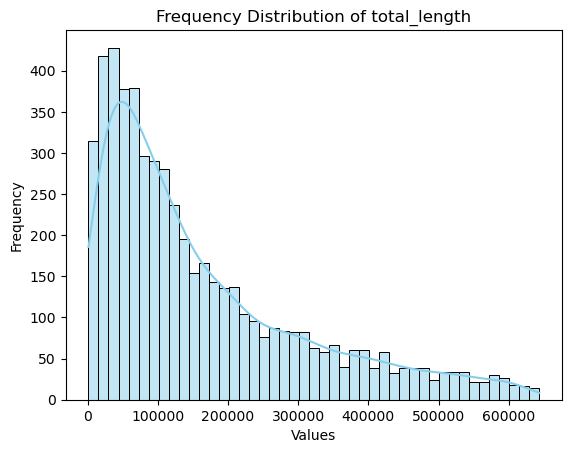

In [218]:
# x = find_scale_parameters(stocks_with_pop, infra_col= 'per_cap_mass_40', pop_col = 'CensusPop_20')

column_name = 'total_length' # 'per_cap_mass'
sns.histplot(stocks_with_pop[column_name], bins=45, kde=True, color='skyblue', edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of ' + str(column_name))
plt.show()

In [219]:
# stocks_with_pop['per_cap_mass_40'].plot()
# plt.scatter(stocks_with_pop['per_cap_mass_40'], stocks_with_pop['per_cap_mass'])
# np.exp(x[2].Intercept) * stocks_with_pop.loc[:, 'CensusPop_20']**x[2].x

In [34]:
# fig = px.scatter(stocks_with_pop, x='road_area', y='building_mass_reg', hover_data=['GEOID', 'NAMELSAD']) 
# fig

### Impute no of lanes

In [181]:
# RHODE ISLAND =44
# df = df_combined[df_combined['State'] == 44]

In [35]:
# # Define a dictionary to map width values # width in meter
# width_mapping = {'motorway' : 27.2, 'trunk' : 19.2, 'primary' : 12.0, 'secondary' : 10.6, 
#                      'tertiary' : 9.8, 'unclassified' : 9.0, 'residential' : 9.0}

# # Use the map function to create a new column based on the dictionary mapping
# df_combined['road_width'] = df_combined['link_type_name'].map(width_mapping)

In [ ]:
# import pandas as pd
# from sklearn.metrics.pairwise import euclidean_distances

# def impute_lanes(df):
#     # Create a copy of the DataFrame to avoid modifying the original
#     df_copy = df.copy()

#     # Iterate through rows with missing 'no_of_lanes'
#     for index, row in df_copy[df_copy['no_of_lanes'].isnull()].iterrows():
#         # Filter rows with the same 'road_class' and 'location'
#         similar_rows = df_copy[(df_copy['road_class'] == row['road_class']) & (df_copy['location'] == row['location'])]

#         if not similar_rows.empty:
#             # Calculate Euclidean distances based on 'no_of_lanes'
#             distances = euclidean_distances([[row['no_of_lanes']]], similar_rows[['no_of_lanes']])
            
#             # Consider rows with small distances
#             close_rows = similar_rows[distances.flatten() < 2.0]  # Adjust the threshold as needed

#             if not close_rows.empty:
#                 # Impute missing value with the median of close values
#                 df_copy.at[index, 'no_of_lanes'] = close_rows['no_of_lanes'].median()

#     return df_copy

# # Example usage:
# # Assuming 'your_dataframe' is your actual DataFrame
# # Replace it with the actual name of your DataFrame
# your_dataframe = pd.DataFrame(...)  # Your actual data here
# result_dataframe = impute_lanes(your_dataframe)

# # Display the result
# print(result_dataframe)


In [ ]:
# # finding nearest lines and assigning the lane number based on the nearest roads
# sample_gdf['min_distances'] = np.nan
# sample_gdf.loc[sample_missing_lanes.index, 'min_distances'] = sample_missing_lanes.geometry.apply(lambda x: sample_with_lanes.distance(x).min())

# min_distances_idx = sample_missing_lanes.geometry.apply(lambda x: sample_with_lanes.distance(x).idxmin())
# # len(min_distances)

# for i,j in zip(sample_missing_lanes.index,min_distances_idx):
#     if sample_gdf.loc[i, 'min_distances'] <= 100:
#         # print(i,j)
#         sample_gdf.loc[i, 'lanes'] = sample_gdf.loc[j,'lanes']

### Waterlines: assumed that total length of residential roads and unclassified roads 

In [434]:
df_combined = df_out.merge(df_population[['GEOID', 'CensusPop_20', 'label','city type', 'State', 
                                          'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060',
                                         'weighted_HU_density_sqmi', 'density_km2']],
                          how = 'left')
print(df_combined.shape)
df_combined.columns

(31554, 25)


Index(['Unnamed: 0', 'motorway_roads', 'trunk_roads', 'primary_roads',
       'secondary_roads', 'tertiary_roads', 'unclassified_roads',
       'residential_roads', 'degree', 'degree_total', 'STATEFP', 'GEOID',
       'NAMELSAD', 'total_length', 'CensusPop_20', 'label', 'city type',
       'State', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060',
       'weighted_HU_density_sqmi', 'density_km2'],
      dtype='object')

In [435]:
df_population.columns

Index(['GEOID', 'NAME', 'NAMELSAD', 'LSAD', 'ALAND', 'CensusPop_20', 'label',
       'State', 'ssp12020', 'ssp22020', 'ssp32020', 'ssp42020', 'ssp52020',
       'ssp12030', 'ssp22030', 'ssp32030', 'ssp42030', 'ssp52030', 'ssp12040',
       'ssp22040', 'ssp32040', 'ssp42040', 'ssp52040', 'ssp12050', 'ssp22050',
       'ssp32050', 'ssp42050', 'ssp52050', 'ssp12060', 'ssp22060', 'ssp32060',
       'ssp42060', 'ssp52060', 'ssp12070', 'ssp22070', 'ssp32070', 'ssp42070',
       'ssp52070', 'ssp12080', 'ssp22080', 'ssp32080', 'ssp42080', 'ssp52080',
       'ssp12090', 'ssp22090', 'ssp32090', 'ssp42090', 'ssp52090', 'ssp12100',
       'ssp22100', 'ssp32100', 'ssp42100', 'ssp52100',
       'future trend from SSP 1', 'future trend from SSP 2',
       'future trend from SSP 3', 'future trend from SSP 4',
       'future trend from SSP 5', 'city type', 'weighted_HU_density_sqmi',
       'density_km2'],
      dtype='object')

In [436]:
# df_combined.isna().sum()

In [437]:
df_combined['waterpipes'] = df_combined['residential_roads']  + df_combined['unclassified_roads'] 

In [438]:
# df_combined[['waterpipes', 'residential_roads', 'unclassified_roads']]

In [439]:
# MILES OF WATER PIPES 
print('Persons served per mile of water pipe: ===')
print(f'In 2016 from Walton (2016): {326/1.2}')
total_pipe_length = df_combined['waterpipes'].sum() 
total_place_population = df_combined['CensusPop_20'].sum() 
print(f'In 2022 from OSM considering residential and unclassified roads: {331900000 / (total_pipe_length * 0.000621371)}')
df_combined['waterpipes'].sum() * 0.000621371

Persons served per mile of water pipe: ===
In 2016 from Walton (2016): 271.6666666666667
In 2022 from OSM considering residential and unclassified roads: 163.84723878114943


2025667.3378751194

In [440]:
excel_file_path = r'D:\Work\Box Sync\Quantify Infrastructure\Water Distribution Lines_from literature\from_water_main_breaks.xlsx'
# sheet_name = 'ST_2_Region'

# Read the specified sheet from the Excel file into a DataFrame
df_water_breaks_1 = pd.read_excel(excel_file_path, sheet_name='ST_2_Region')
df_water_breaks_2 = pd.read_excel(excel_file_path, sheet_name='lengthByMat_byReg', header =1)
df_water_breaks_3 = pd.read_excel(excel_file_path, sheet_name='ageDistribution')

In [441]:
# df_water_breaks_3

In [442]:
df_water_breaks = df_water_breaks_1.merge(df_water_breaks_2, on = 'W_REGION')

In [443]:
df_water_breaks.columns

Index(['W_REGION', 'STATE', 'NAME', 'STATEFP', 'AC', 'CI', 'CSC', 'DI',
       'Steel', 'PVC', 'Other'],
      dtype='object')

In [444]:
df_combined = df_combined.merge(df_water_breaks, on = 'STATEFP')

In [445]:
(df_combined.groupby('W_REGION')['CensusPop_20'].sum() / (df_combined.groupby('W_REGION')['waterpipes'].sum() * 0.000621371))

W_REGION
1    133.198710
2     23.319120
3     47.476501
4     81.668609
5     75.668166
6    118.551501
7     83.705299
8    169.872018
dtype: float64

In [446]:
df_combined.groupby('W_REGION')['waterpipes'].sum() * 0.000621371

W_REGION
1     84117.646742
2    187911.978371
3     91615.218310
4    150361.982457
5    402578.065460
6    330032.684727
7    470992.534471
8    297199.171940
Name: waterpipes, dtype: float64

In [447]:
df_housing_age = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\Housing Data ACS\HousingDataCleaned.csv', 
                             index_col = 0,)[['GEOID', 'HUs_Total','Year_Built', 'Percent_Built']]

In [448]:
df_housing_age['GEOID'] = df_housing_age['GEOID'].str[9:]
df_combined = df_combined.merge(df_housing_age, on = 'GEOID')

In [449]:
df_combined['Mode_HU_age'] = 2024 - df_combined['Year_Built'].str.split('_').str[-1].astype(float)

In [450]:
df_combined.columns

Index(['Unnamed: 0', 'motorway_roads', 'trunk_roads', 'primary_roads',
       'secondary_roads', 'tertiary_roads', 'unclassified_roads',
       'residential_roads', 'degree', 'degree_total', 'STATEFP', 'GEOID',
       'NAMELSAD', 'total_length', 'CensusPop_20', 'label', 'city type',
       'State', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060',
       'weighted_HU_density_sqmi', 'density_km2', 'waterpipes', 'W_REGION',
       'STATE', 'NAME', 'AC', 'CI', 'CSC', 'DI', 'Steel', 'PVC', 'Other',
       'HUs_Total', 'Year_Built', 'Percent_Built', 'Mode_HU_age'],
      dtype='object')

In [453]:
df_combined[['waterpipes', 'W_REGION', 'STATE', 'NAMELSAD', 'AC', 'CI', 'CSC', 'DI',
             'Steel', 'PVC', 'Other', 'HUs_Total', 'Year_Built', 'Percent_Built', 'Mode_HU_age', 'CensusPop_20',
            'weighted_HU_density_sqmi']].sort_values('Percent_Built')

,waterpipes,W_REGION,STATE,NAMELSAD,AC,CI,CSC,DI,Steel,PVC,Other,HUs_Total,Year_Built,Percent_Built,Mode_HU_age,CensusPop_20,weighted_HU_density_sqmi
25902,231686.63,7,TN,Lenoir City city,4,28,2,47,2,13,4,3826,YB_<=_1939,18.4,85.0,10117.0,576.731633
16598,15733.12,8,NJ,Mantoloking borough,7,39,2,36,1,12,3,177,YB_2000_2009,19.2,15.0,331.0,1767.901073
13047,67282.69,6,MN,Norwood Young America city,1,43,3,43,0,7,3,1344,YB_1980_1999,19.3,25.0,3863.0,55.055522
7740,100318.53,6,IN,Nappanee city,1,43,3,43,0,7,3,2741,YB_<=_1939,19.5,85.0,6949.0,591.311323
6296,41822.12,6,IL,Fisher village,1,43,3,43,0,7,3,667,YB_<=_1939,19.6,85.0,2062.0,12.664105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31224,13762.80,3,WY,Owl Creek CDP,11,25,2,22,6,33,2,0,NaN,NaN,NaN,4.0,0.538824
31228,15567.06,3,WY,Powder River CDP,11,25,2,22,6,33,2,0,NaN,NaN,NaN,30.0,0.421022
31235,20549.26,3,WY,Robertson CDP,11,25,2,22,6,33,2,0,NaN,NaN,NaN,95.0,1.365051
31244,2720.06,3,WY,Table Rock CDP,11,25,2,22,6,33,2,0,NaN,NaN,NaN,0.0,NaN


In [427]:
df_combined[['Percent_Built', 'Mode_HU_age']].describe()
df_combined[['Percent_Built', 'Mode_HU_age']].isna().sum()

Percent_Built    485
Mode_HU_age      485
dtype: int64

In [383]:
df_water_breaks_3

,MATERIAL,0-10,10-20,20-50,>50
0,AC,0,0,73,27
1,CI,0,0,18,82
2,CSC,4,16,50,30
3,DI,19,26,55,0
4,Steel,7,12,43,37
5,PVC,23,43,34,0
6,Other,26,17,27,30


In [335]:
# Choose 'Category' as the column you want to map
mapping_column = 'MATERIAL'
# Create a dictionary to map 'Category' to the other three columns
mapping_dict = df_water_breaks_3.set_index(mapping_column)[['0-10', '10-20', '20-50', '>50']].to_dict(orient='index')
# Display the dictionary
print(mapping_dict)


{'AC': {'0-10': 0, '10-20': 0, '20-50': 73, '>50': 27}, 'CI': {'0-10': 0, '10-20': 0, '20-50': 18, '>50': 82}, 'CSC': {'0-10': 4, '10-20': 16, '20-50': 50, '>50': 30}, 'DI': {'0-10': 19, '10-20': 26, '20-50': 55, '>50': 0}, 'Steel': {'0-10': 7, '10-20': 12, '20-50': 43, '>50': 37}, 'PVC': {'0-10': 23, '10-20': 43, '20-50': 34, '>50': 0}, 'Other': {'0-10': 26, '10-20': 17, '20-50': 27, '>50': 30}}


In [466]:
### STEPS;
# 1. Sample age and material from distribution
# 2. Assign HU density based threshold to sepearte wells vs distribution system
#    ref: file:///C:/Users/uttar/Downloads/JohnsonSTOTEN2019.pdf
# 3. How many new water distributions lines are being addded??
#    Using scaling law find the addtional added length for population 
#    Based on HU density check if it HU_current > threshold => Scaling length else HU_cureent < threshold =>   

,0,1,2
Material,Wood,Metal,Concrete
Distribution,"[0.2, 0.5, 0.3]","[0.1, 0.3, 0.6]","[0.4, 0.4, 0.2]"


In [469]:
# import pandas as pd
# import numpy as np

# # Example DataFrame for materials
# data_materials = {
#     'Material': ['Wood', 'Metal', 'Concrete'],
#     'Distribution': [[0.2, 0.5, 0.3], [0.1, 0.3, 0.6], [0.4, 0.4, 0.2]]
# }

# df_materials = pd.DataFrame(data_materials)

# # Example DataFrame for age structure
# data_age_structure = {
#     'Structure_ID': [1, 2, 3, 4, 5],
#     'Age': [10, 25, 15, 30, 20],
#     'Length': [50, 30, 40, 60, 45]  # Example column for structure length
# }

# df_age_structure = pd.DataFrame(data_age_structure)

# # Function to sample material based on age and calculate length for each material
# def sample_and_calculate_length(row):
#     material_distribution = row['Distribution']
#     sampled_material = np.random.choice(df_materials['Material'], p=material_distribution)
#     return row['Length'] * material_distribution[df_materials.index[df_materials['Material'] == sampled_material][0]]

# # Apply the sampling and length calculation function to create a new column 'Sampled_Material' and 'Material_Length'
# df_age_structure['Sampled_Material'] = df_age_structure.apply(sample_and_calculate_length, axis=1)
# df_age_structure['Material_Length'] = df_age_structure.apply(lambda row: row['Length'] * row['Sampled_Material'], axis=1)

# # Display the result
# print(df_age_structure[['Structure_ID', 'Age', 'Length', 'Sampled_Material', 'Material_Length']])


(31026, 40)


C:\Users\uttar\AppData\Local\Temp\ipykernel_19988\464284895.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\uttar\AppData\Local\Temp\ipykernel_19988\464284895.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



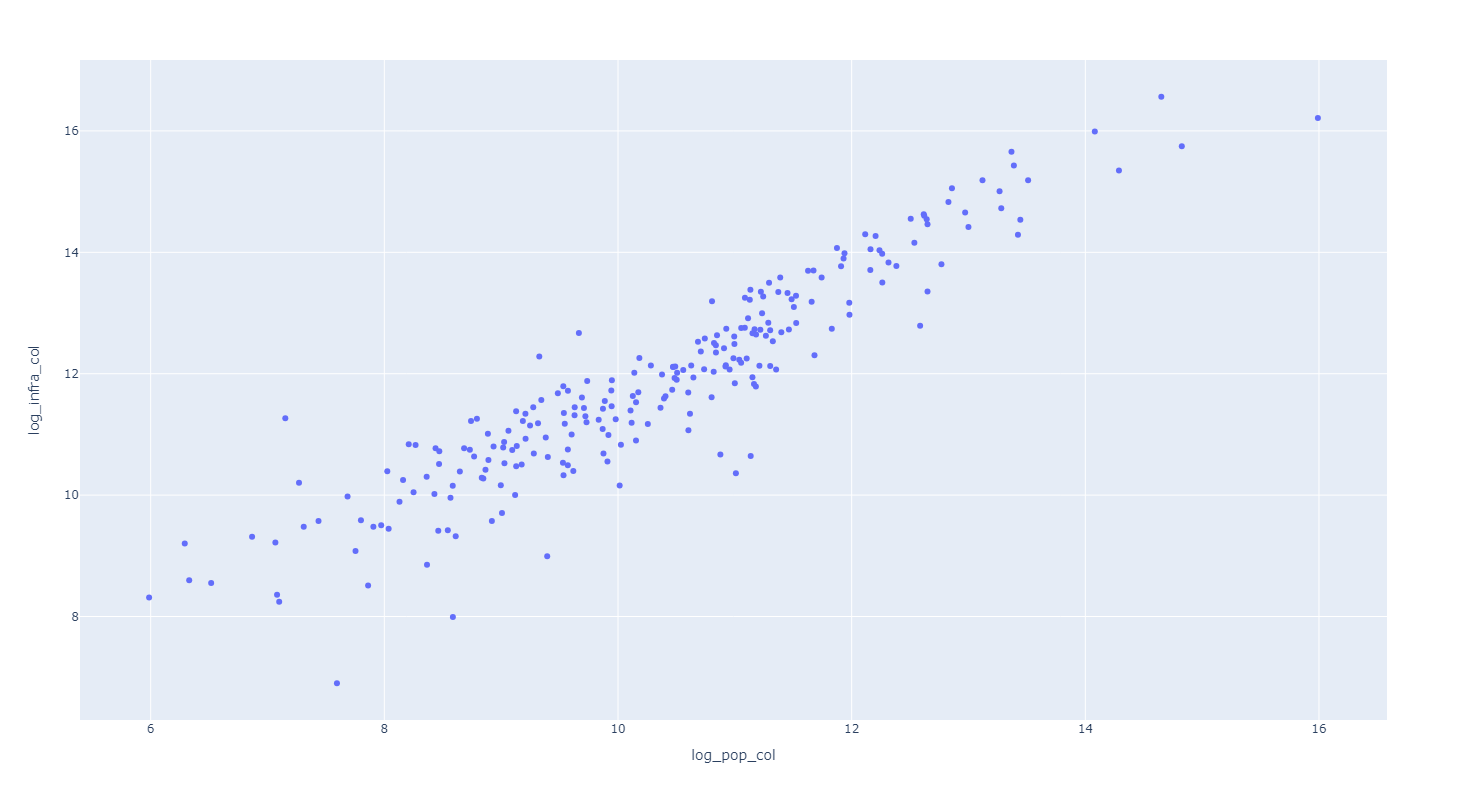

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     1521.
Date:                Wed, 21 Feb 2024   Prob (F-statistic):          2.30e-105
Time:                        14:51:41   Log-Likelihood:                -227.74
No. Observations:                 240   AIC:                             459.5
Df Residuals:                     238   BIC:                             466.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.2160      0.251      8.846      0.0

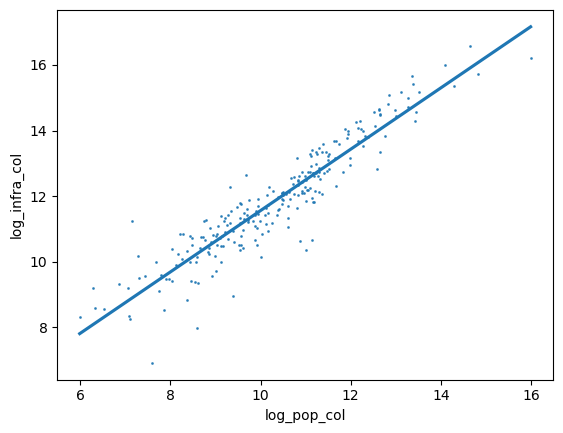

In [471]:
df_combined = df_combined[(df_combined['waterpipes'] != 0) & (df_combined['CensusPop_20'] != 0)]
df_combined_city = df_combined[df_combined['CensusPop_20'] != 0]
print(df_combined_city.shape)
stocks_with_pop = df_combined_city[df_combined_city['city type'] == 'urban']

existing_stock_col = 'waterpipes'

x = find_scale_parameters(stocks_with_pop, infra_col= existing_stock_col, pop_col = 'CensusPop_20')

C:\Users\uttar\AppData\Local\Temp\ipykernel_19988\464284895.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\uttar\AppData\Local\Temp\ipykernel_19988\464284895.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



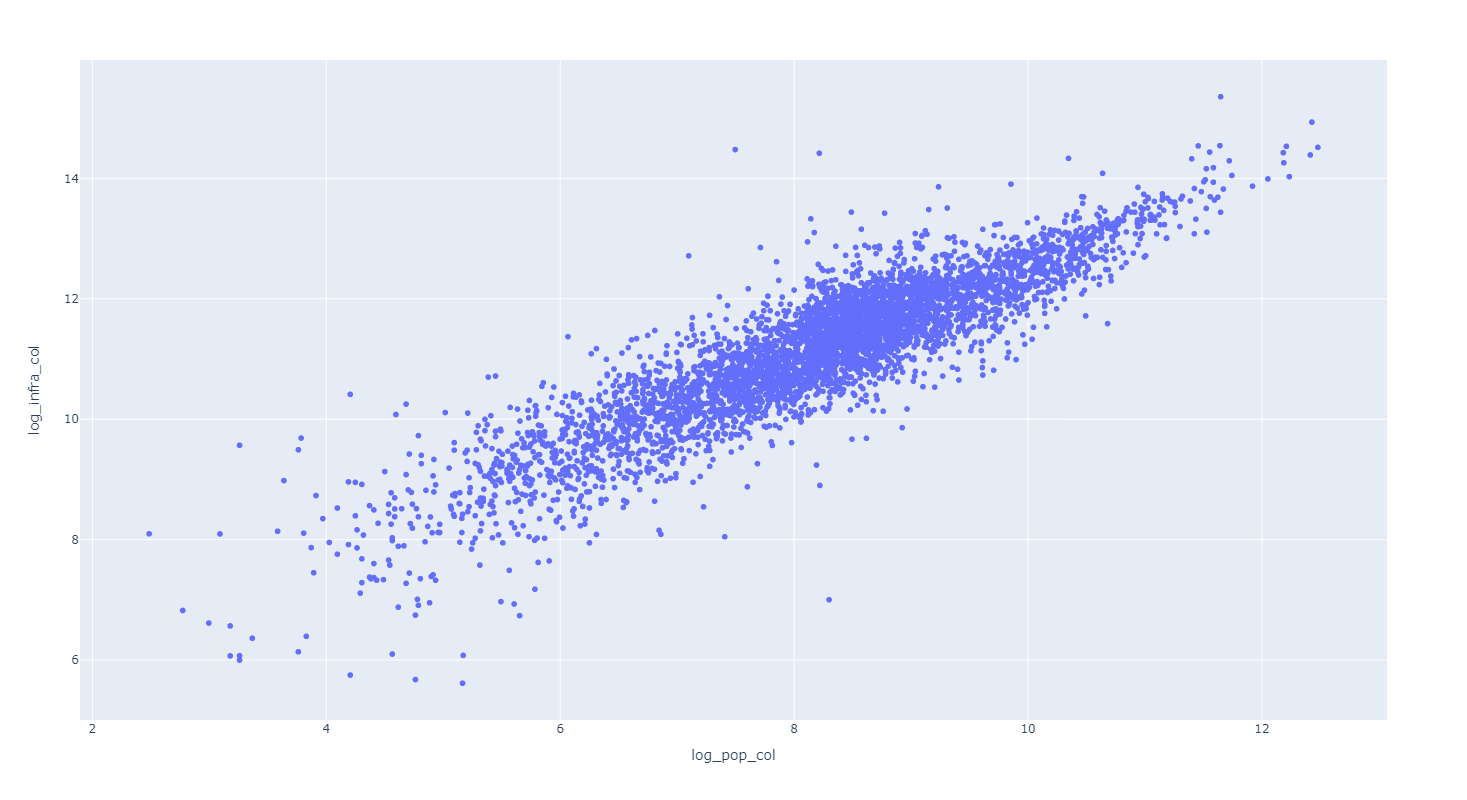

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                 1.962e+04
Date:                Wed, 21 Feb 2024   Prob (F-statistic):               0.00
Time:                        03:21:15   Log-Likelihood:                -3739.3
No. Observations:                4807   AIC:                             7483.
Df Residuals:                    4805   BIC:                             7496.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7696      0.046    103.059      0.0

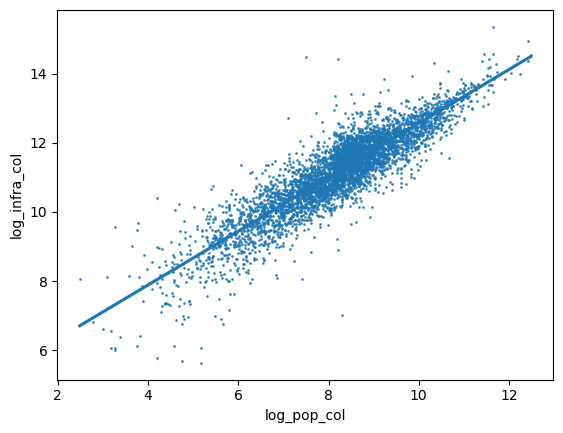

In [314]:
df_combined = df_combined[(df_combined['waterpipes'] != 0) & (df_combined['CensusPop_20'] != 0)]
df_combined_city = df_combined[df_combined['CensusPop_20'] != 0]
stocks_with_pop = df_combined_city[df_combined_city['city type'] == 'periurban']

existing_stock_col = 'waterpipes'

x = find_scale_parameters(stocks_with_pop, infra_col= existing_stock_col, pop_col = 'CensusPop_20')

In [473]:
# sns.relplot(data = df_combined, y= 'residential_roads', x = 'CensusPop_20')
# sns.pairplot(data = df_combined, y_vars=['residential_roads', 'primary_roads'], x_vars=['CensusPop_20'], height=5, aspect=.8, kind="reg");
# sns.lmplot(data = df_combined, y = 'waterpipes', x='CensusPop_20', order=2, ci=None, scatter_kws={"s": 80});

# Create spanning tree

In [ ]:
import libpysal
from libpysal import cg
import spaghetti

In [ ]:
def plotter(net_arcs, net_verts, mst_arcs=None, mst_verts=None, label=True):
    """Convenience plotting function."""
    plot_mst, msize, vert_z = False, 40, 3
    if hasattr(mst_arcs, "T") and hasattr(mst_verts, "T"):
        plot_mst, msize, vert_z = True, 20, 4
    # set arc keyword arguments
    arc_kws = {"column":"comp_label", "cmap":"Paired"}
    # set the streets as the plot base
    base_kws = {"figsize":(12, 12)}
    base_kws.update(arc_kws)
    base = net_arcs.plot(lw=5, alpha=.9, **base_kws)
    # create vertices keyword arguments for matplotlib
    ax_kwargs = {"ax":base}
    net_verts.plot(color="k", markersize=msize, zorder=vert_z, **ax_kwargs)
    # plot spanning trees
    if plot_mst:
        mst_arcs.plot(color="k", lw=3, zorder=2, alpha=.9, **ax_kwargs)
        mst_verts.plot(color="r", markersize=100, zorder=3, **ax_kwargs)
    # label network/tree elements
    if label:
        if not plot_mst:
            arc_labels(net_arcs, base, 12)
            vert_labels(net_verts, base, 14)
        else:
            arc_labels(mst_arcs, base, 12)
            vert_labels(mst_verts, base, 14)

def arc_labels(a, b, s):
    """Label each network arc."""
    def _lab_loc(_x):
        """Helper for labeling network arcs."""
        return _x.geometry.interpolate(0.5, normalized=True).coords[0]
    kws = {"size": s, "ha": "center", "va": "bottom"}
    a.apply(lambda x: b.annotate(text=x.id, xy=_lab_loc(x), **kws), axis=1)

def vert_labels(v, b, s):
    """Label each network vertex."""
    def _lab_loc(_x):
        """Helper for labeling vertices."""
        return _x.geometry.coords[0]
    kws = {"size": s, "ha": "left", "va": "bottom", "weight": "bold"}
    v.apply(lambda x: b.annotate(text=x.id, xy=_lab_loc(x), **kws), axis=1)

In [ ]:
elem_kws = {"vertices":True, "arcs":True}

In [ ]:
ntw = spaghetti.Network(in_data=gdf)
vertices, arcs = spaghetti.element_as_gdf(ntw, **elem_kws)

In [ ]:
plotter(arcs, vertices, mst_arcs=None, mst_verts=None, label=False)

In [ ]:
minst_net = spaghetti.spanning_tree(ntw)
mst_verts, mst_arcs = spaghetti.element_as_gdf(minst_net, **elem_kws)
plotter(arcs, vertices, mst_arcs=mst_arcs, mst_verts=mst_verts, label=False)

In [ ]:
gdf = Sheldon_roads[(Sheldon_roads['link_type'] >4) & (Sheldon_roads['link_type'] <8)]
ntw = spaghetti.Network(in_data=gdf)
vertices, arcs = spaghetti.element_as_gdf(ntw, **elem_kws)
plotter(arcs, vertices, mst_arcs=None, mst_verts=None, label=False)

In [ ]:
minst_net = spaghetti.spanning_tree(ntw)
mst_verts, mst_arcs = spaghetti.element_as_gdf(minst_net, **elem_kws)
plotter(arcs, vertices, mst_arcs=mst_arcs, mst_verts=mst_verts, label=False)

In [ ]:
# Total length of minimum spanning tree
# project to a linear scale projection and then measure the length
min_len = sum(minst_net.arc_lengths.values())
min_len

In [ ]:
maxst_net = spaghetti.spanning_tree(ntw, maximum=True)
max_len = sum(maxst_net.arc_lengths.values())
max_len

In [ ]:
# # snapping another geodataframe to the network 
# ntw.snapobservations(
#     libpysal.examples.get_path("places_centroid_shapefile.shp"), "cities", attribute=False
# )

In [ ]:
def plotter(net_arcs, net_verts, mst_arcs=None, mst_verts=None, label=True):
    """Convenience plotting function."""
    plot_mst, msize, vert_z = False, 40, 3
    if hasattr(mst_arcs, "T") and hasattr(mst_verts, "T"):
        plot_mst, msize, vert_z = True, 20, 4
    # set arc keyword arguments
    arc_kws = {"column":"comp_label", "cmap":"Paired"}
    # set the streets as the plot base
    base_kws = {"figsize":(12, 12)}
    base_kws.update(arc_kws)
    base = net_arcs.plot(lw=5, alpha=.9, **base_kws)
    # create vertices keyword arguments for matplotlib
    ax_kwargs = {"ax":base}
    net_verts.plot(color="k", markersize=msize, zorder=vert_z, **ax_kwargs)
    # plot spanning trees
    if plot_mst:
        mst_arcs.plot(color="k", lw=3, zorder=2, alpha=.9, **ax_kwargs)
        mst_verts.plot(color="r", markersize=100, zorder=3, **ax_kwargs)
    # label network/tree elements
    if label:
        if not plot_mst:
            arc_labels(net_arcs, base, 12)
            vert_labels(net_verts, base, 14)
        else:
            arc_labels(mst_arcs, base, 12)
            vert_labels(mst_verts, base, 14)

def arc_labels(a, b, s):
    """Label each network arc."""
    def _lab_loc(_x):
        """Helper for labeling network arcs."""
        return _x.geometry.interpolate(0.5, normalized=True).coords[0]
    kws = {"size": s, "ha": "center", "va": "bottom"}
    a.apply(lambda x: b.annotate(text=x.id, xy=_lab_loc(x), **kws), axis=1)

def vert_labels(v, b, s):
    """Label each network vertex."""
    def _lab_loc(_x):
        """Helper for labeling vertices."""
        return _x.geometry.coords[0]
    kws = {"size": s, "ha": "left", "va": "bottom", "weight": "bold"}
    v.apply(lambda x: b.annotate(text=x.id, xy=_lab_loc(x), **kws), axis=1)

In [ ]:
ntw = spaghetti.Network(in_data=r"D:\Work\Box Sync\TRB 2024\shapefiles\file.shp")
elem_kws = {"vertices":True, "arcs":True}
vertices, arcs = spaghetti.element_as_gdf(ntw, **elem_kws)

In [ ]:
plotter(arcs, vertices, mst_arcs=None, mst_verts=None, label=False)

In [ ]:
minst_net = spaghetti.spanning_tree(ntw)
mst_verts, mst_arcs = spaghetti.element_as_gdf(minst_net, **elem_kws)
plotter(arcs, vertices, mst_arcs=mst_arcs, mst_verts=mst_verts, label=False)

# Import IL places from Census and Clip

In [15]:
# reading the zip file
shapefiles = gpd.read_file(r"D:\Work\Box Sync\TRB 2024\US_places_2020\tl_2020_17_place.zip")

In [ ]:
Sheldon_village = shapefiles[shapefiles['NAMELSAD'] == 'Sheldon village']
Sheldon_roads = gpd.clip(state_streets, Sheldon_village.to_crs(state_streets.crs))

print(Sheldon_roads.shape)
Sheldon_roads[(Sheldon_roads['link_type'] >2) & (Sheldon_roads['link_type'] <=15)].plot()

In [ ]:
Sheldon_roads_major = Sheldon_roads[(Sheldon_roads['link_type'] >4) & (Sheldon_roads['link_type'] <8)]
Sheldon_roads_major.plot()

In [ ]:
Chicago_city = shapefiles[shapefiles['NAMELSAD'] == 'Chicago city']
Chicago_roads =  gpd.clip(state_streets, Chicago_city.to_crs(state_streets.crs))

In [ ]:
Chicago_roads.columns, Chicago_roads.crs

In [ ]:
# Chicago_roads.head(2)

# Import potholes from Chicago Data Portal

In [ ]:
CDP_potholes = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\Roadway Performance Data\311_Service_Requests_-_Pot_Holes_Reported_-_Historical_20231103.csv')

In [ ]:
CDP_potholes['year_created'] = pd.to_datetime(CDP_potholes['CREATION DATE'], format='%m/%d/%Y').dt.year
CDP_potholes['year_completed'] = pd.to_datetime(CDP_potholes['COMPLETION DATE'], format='%m/%d/%Y').dt.year

In [ ]:
CDP_potholes[['LATITUDE', 'LONGITUDE', 'X COORDINATE', 'Y COORDINATE', 
              'NUMBER OF POTHOLES FILLED ON BLOCK']] = CDP_potholes[['LATITUDE', 'LONGITUDE', 
              'X COORDINATE', 'Y COORDINATE', 'NUMBER OF POTHOLES FILLED ON BLOCK']].apply(pd.to_numeric, errors='coerce')

CDP_potholes.shape

In [ ]:
CDP_potholes_cleaned = CDP_potholes[(CDP_potholes['STATUS'] != 'Completed - Dup') & (CDP_potholes['STATUS'] != 'Open - Dup')]
CDP_potholes_cleaned.shape

In [ ]:
# from pyproj import CRS #CRS("ESRI:54009")
from shapely import Point
# creating a geometry column 
geometry = [Point(xy) for xy in zip(CDP_potholes_cleaned['LONGITUDE'], CDP_potholes_cleaned['LATITUDE'])]
# Coordinate reference system : WGS84
crs = 'EPSG:4326'
# Creating a Geographic data frame 
gdf = gpd.GeoDataFrame(CDP_potholes_cleaned, crs=crs, geometry=geometry)

In [ ]:
# gdf.bounds

In [ ]:
# Reading the input CRS. 
input_crs = gdf.crs

# Reprojecting the data. If needed, substitute "WXYZ" with 
# relevant EPSG code. Learn more here: https://spatialreference.org/ref/epsg/
# Comment out if unnecessary for your specific case.
gdf = gdf.to_crs('EPSG:32616')

# Creating the variable-sized buffer
gdf['buffer'] = gdf.buffer(2, cap_style=3) 

# Dropping the original geometry and setting the new geometry
buffer_gdf = gdf.drop(columns=['geometry']).set_geometry('buffer')


In [ ]:
import spaghetti as spgh
# streets_file = examples.get_path('streets.shp')
ntw = spgh.Network(in_data=state_streets_major)
pt_str = 'potholes'
in_data = gdf
ntw.snapobservations(in_data, pt_str, attribute=True)
ntw.pointpatterns[pt_str].npoints

# Joining pothole data with OSM Network 
Create 2 m buffer arround potholes and sjoin with Chicago roads clipped by places data

In [44]:
state_streets = links.to_crs('EPSG:32616')

<Axes: >

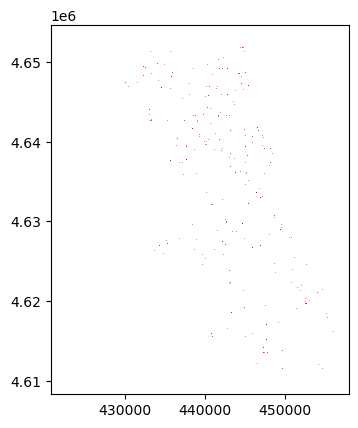

In [45]:
# ax = Chicago_roads.plot(alpha = 0.5,)
buffer_gdf.plot(alpha = 0.5, color = 'red')

In [46]:
gdf_roads = gpd.sjoin(links, buffer_gdf, how='inner', predicate='intersects')

C:\Users\uttar\AppData\Local\Temp\ipykernel_20796\972007655.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:32616

  gdf_roads = gpd.sjoin(links, buffer_gdf, how='inner', predicate='intersects')


In [47]:
gdf_roads.shape

(0, 40)

In [ ]:
# Chicago_roads['link_id'].nunique(), Chicago_roads.shape

In [48]:
gdf_roads.columns

Index(['name', 'link_id', 'osm_way_id', 'from_node_id', 'to_node_id',
       'dir_flag', 'length', 'lanes', 'free_speed', 'capacity',
       'link_type_name', 'link_type', 'allowed_uses', 'from_biway', 'is_link',
       'VDF_fftt1', 'VDF_cap1', 'geometry', 'index_right', 'CREATION DATE',
       'STATUS', 'COMPLETION DATE', 'SERVICE REQUEST NUMBER',
       'TYPE OF SERVICE REQUEST', 'CURRENT ACTIVITY', 'MOST RECENT ACTION',
       'NUMBER OF POTHOLES FILLED ON BLOCK', 'STREET ADDRESS', 'ZIP',
       'X COORDINATE', 'Y COORDINATE', 'Ward', 'Police District',
       'Community Area', 'SSA', 'LATITUDE', 'LONGITUDE', 'LOCATION',
       'year_created', 'year_completed'],
      dtype='object')

In [50]:
# gdf_roads[gdf_roads['Community Area'] == '31'].groupby(['Community Area','year_created', 'MOST RECENT ACTION']).size().head(35) # [gdf_roads['Community Area'] == '8']

In [51]:
gdf_roads['name'].nunique(), gdf_roads['Community Area'].nunique()

(0, 0)

In [52]:
gdf_roads.columns

Index(['name', 'link_id', 'osm_way_id', 'from_node_id', 'to_node_id',
       'dir_flag', 'length', 'lanes', 'free_speed', 'capacity',
       'link_type_name', 'link_type', 'allowed_uses', 'from_biway', 'is_link',
       'VDF_fftt1', 'VDF_cap1', 'geometry', 'index_right', 'CREATION DATE',
       'STATUS', 'COMPLETION DATE', 'SERVICE REQUEST NUMBER',
       'TYPE OF SERVICE REQUEST', 'CURRENT ACTIVITY', 'MOST RECENT ACTION',
       'NUMBER OF POTHOLES FILLED ON BLOCK', 'STREET ADDRESS', 'ZIP',
       'X COORDINATE', 'Y COORDINATE', 'Ward', 'Police District',
       'Community Area', 'SSA', 'LATITUDE', 'LONGITUDE', 'LOCATION',
       'year_created', 'year_completed'],
      dtype='object')

In [53]:
gdf_roads.shape

(0, 40)

In [54]:
gdf_roads['STATUS'].value_counts()

Series([], Name: count, dtype: int64)

In [55]:
gdf_roads[['STATUS', 'CURRENT ACTIVITY', 'MOST RECENT ACTION',
           'NUMBER OF POTHOLES FILLED ON BLOCK', 'year_created']] #.isna().sum()

,STATUS,CURRENT ACTIVITY,MOST RECENT ACTION,NUMBER OF POTHOLES FILLED ON BLOCK,year_created


ValueError: aspect must be finite and positive 

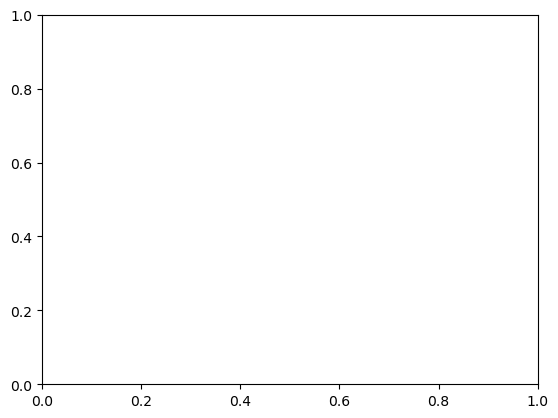

In [56]:
gdf_roads.plot(column = 'NUMBER OF POTHOLES FILLED ON BLOCK', legend= True)

In [ ]:
gdf_roads['NUMBER OF POTHOLES FILLED ON BLOCK'].isna().sum(), gdf_roads.shape

In [ ]:
gdf_roads['NUMBER OF POTHOLES FILLED ON BLOCK'].isna().sum(), gdf_roads.shape

# Import places map and clip

In [ ]:
US_places_raw = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
US_places = US_places_raw.to_crs('EPSG:32616')

In [ ]:
boundaries = US_places[US_places['STATEFP'] == '17']

In [ ]:
bound_chicago = boundaries[boundaries['NAME'] == 'Chicago']

In [ ]:
ax = gdf_roads.plot()
boundaries[boundaries['NAME'] == 'Chicago'].plot(ax=ax, alpha = 0.5)

In [ ]:
clipped_gdf_roads = gpd.clip(gdf_roads, bound_chicago)

In [ ]:
clipped_gdf_roads.columns, clipped_gdf_roads.shape

In [ ]:
clipped_gdf_roads.groupby(['year_created', 'Community Area','link_type'])['NUMBER OF POTHOLES FILLED ON BLOCK'].sum().tail(15)

In [ ]:
# clipped = [gpd.clip(gdf_roads, b) for b in boundaries]

# Roadway performance data

In [13]:
gisdata = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\Roadway Performance Data\IL\2022-PM2_Pavement\commondata\gisdata\Table1.shp')
gisdata1 = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\Roadway Performance Data\IL\2022-PM2_Pavement\commondata\gisdata1\Table1.shp')
gisdata2 = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\Roadway Performance Data\IL\2022-PM2_Pavement\commondata\gisdata2\Table1.shp')

In [14]:
df_roadwayPerfrom = pd.concat([gisdata, gisdata1, gisdata2], axis=0, join='outer', ignore_index=True)
df_roadwayPerfrom['Year_perfrm'] = pd.to_datetime(df_roadwayPerfrom['TenthOfa_6']).dt.year

In [15]:
# rural places are encoded as '0000' and roads outside places has been encoded as 0. 
# therefore renaming the municipalities
def is_Actualmunicipality(x):
    name = x
    if x == '0000':
        name = 'rural place'
    if x == 0:
        name = 'not a place'
    return (name)

df_roadwayPerfrom['NAME'] = df_roadwayPerfrom['Municipali'].apply(is_Actualmunicipality)


In [16]:
# df_rw_Sheldon = df_roadwayPerfrom[df_roadwayPerfrom['NAME'] == 'Sheldon']
# Sheldon_roads.sjoin(df_rw_Sheldon.to_crs(Sheldon_roads.crs))

In [17]:
df_rw_Chicago = df_roadwayPerfrom[df_roadwayPerfrom['NAME'] == 'Chicago']

In [18]:
df_rw_Chicago.columns

Index(['ID', 'InventoryN', 'BeginStati', 'EndStation', 'Length', 'LaneCount',
       'MarkingTyp', 'NHS', 'Municipali', 'TownshipNa', 'CountyName',
       'MPOName', 'JurType', 'Jurisdicti', 'StateJuris', 'Maintenanc',
       'CRS_Low', 'SOAC_Categ', 'TenthOfaMi', 'TenthOfa_1', 'TenthOfa_2',
       'TenthOfa_3', 'TenthOfa_4', 'TenthOfa_5', 'TenthOfa_6', 'PM2IRIRati',
       'PM2RutRati', 'PM2FaultRa', 'PM2CrackPc', 'PM2Overall', 'PrimaryRou',
       'StreetName', 'FirstOf_Be', 'LastOf_Bes', 'ExtractDat', 'LOC_ERROR',
       'geometry', 'Year_perfrm', 'NAME'],
      dtype='object')

In [19]:
df_rw_Chicago['Length'].describe()

count    8871.00000
mean        0.08682
std         0.02628
min         0.01000
25%         0.10000
50%         0.10000
75%         0.10000
max         0.22000
Name: Length, dtype: float64

In [20]:
df_rw_Chicago.crs

<Projected CRS: PROJCS["NAD_1983_StatePlane_Illinois_West_FIPS_120 ...>
Name: NAD83 / Illinois West (ftUS)
Axis Info [cartesian]:
- [east]: Easting (US survey foot)
- [north]: Northing (US survey foot)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [21]:
df_rw_Chicago.shape

(8871, 39)

# join HPMS with potholes

In [ ]:
osm_with_hpms =gdf_roads[['name', 'link_id', 'osm_way_id', 'from_node_id', 'to_node_id',
       'dir_flag', 'length', 'lanes', 'free_speed', 'capacity',
       'link_type_name', 'link_type', 'allowed_uses', 'from_biway', 'is_link',
       'VDF_fftt1', 'VDF_cap1', 'geometry', 'CREATION DATE',
       'STATUS', 'COMPLETION DATE', 'SERVICE REQUEST NUMBER',
       'TYPE OF SERVICE REQUEST', 'CURRENT ACTIVITY', 'MOST RECENT ACTION',
       'NUMBER OF POTHOLES FILLED ON BLOCK', 'STREET ADDRESS', 'ZIP',
       'Community Area','year_created', 'year_completed']].sjoin(df_rw_Chicago.to_crs(gdf_roads.crs), how= 'left') #.plot()

In [ ]:
osm_with_hpms.shape, gdf_roads.shape, df_rw_Chicago.shape

In [ ]:
osm_with_hpms.shape, gdf_roads.shape

In [ ]:
gdf_regularroads = osm_with_hpms[(osm_with_hpms['link_type'] < 8) | (osm_with_hpms['link_type'] ==15)]
gdf_footway = osm_with_hpms[(osm_with_hpms['link_type'] == 10)]

In [ ]:
ax = gdf_roads[(gdf_roads['link_type'] < 8) | (gdf_roads['link_type'] ==15)].plot()
gdf_regularroads.plot(ax =ax, column = 'Year_perfrm', legend = True)

In [ ]:
gdf_regularroads.columns

In [ ]:
gdf_regularroads.groupby(['link_type','link_type_name','TenthOfa_4']).agg({'CRS_Low':['mean', 'max', 'count'],
                                                                           'Length': 'sum',                                                                           
                                                                           'NUMBER OF POTHOLES FILLED ON BLOCK':'sum'
                                                                           })

In [ ]:
gdf_regularroads.groupby(['link_type'])['length'].sum()

In [ ]:
Chicago_roads.groupby(['link_type'])['length'].sum()

In [ ]:
pd.crosstab([gdf_regularroads['link_type'], gdf_regularroads['link_type_name']], [gdf_regularroads['TenthOfa_4']], 
            values = gdf_regularroads['CRS_Low'] , aggfunc = 'mean')
# ,'TenthOfa_4', 'PM2IRIRati',       'PM2RutRati', 'PM2FaultRa', 'PM2CrackPc', 'PM2Overall']].min()

In [ ]:
# osm_with_hpms[(osm_with_hpms['link_type'] == 10)][['name', 'length',
#        'link_type_name', 'NUMBER OF POTHOLES FILLED ON BLOCK', 
#        'Community Area', 'year_created', 'NHS', 'Municipali', 'Length', 
#        'CRS_Low',  'PM2CrackPc', 'PM2Overall']].sort_values(by= ['PM2CrackPc', 'year_created', 'Community Area']).head(20)

In [ ]:
osm_with_hpms[(osm_with_hpms['link_type'] <8)].plot(column = 'Community Area')

In [ ]:
osm_with_hpms[(osm_with_hpms['link_type'] < 8)].plot(column = 'CRS_Low', legend = True)

In [ ]:
osm_with_hpms['PM2Overall'] = osm_with_hpms['PM2Overall'].replace(np.nan, 'No_data')
# osm_with_hpms[(osm_with_hpms['link_type'] <8)].plot(column = 'PM2Overall', legend = True)

In [ ]:
# osm_with_hpms[(osm_with_hpms['link_type']< 8) | (osm_with_hpms['link_type'] ==15)][['name', 'length',
#        'link_type_name', 'NUMBER OF POTHOLES FILLED ON BLOCK', 'Community Area', 'year_created', 'NHS', 'Municipali', 'Length', 
#        'CRS_Low',  'PM2CrackPc', 'PM2Overall']].sort_values(by= 'PM2CrackPc')

In [ ]:
osm_with_hpms[['link_type_name', 'link_type', 'Community Area','Maintenanc',
               'year_created', 'NUMBER OF POTHOLES FILLED ON BLOCK', 'Year_perfrm',
       'CRS_Low',  'geometry', 'Municipali', 'TownshipNa', 'CountyName']].dropna().plot()

In [ ]:
# print(osm_with_hpms.iloc[:,31:].isna().sum()), print(osm_with_hpms.shape)

In [ ]:
osm_with_hpms.columns

In [ ]:
# df[df.duplicated(['link_id', 'osm_way_id', 'from_node_id','to_node_id', 'year_created', 'NUMBER OF POTHOLES FILLED ON BLOCK'], keep=False)]

# Try Imputation or no?

In [ ]:
# import pandas as pd
# from sklearn.impute import KNNImputer

# # Sample data with missing values
# data = df.iloc[:,4:].reset_index(drop =True)
# # Index of the row with missing values
# missing_row_index = 2

# # Separate numerical and categorical columns
# numerical_cols = data.select_dtypes(include=[np.number]).columns
# categorical_cols = data.select_dtypes(include=[object]).columns

# # Create a KNN imputer with k=2
# imputer = KNNImputer(n_neighbors=2)

# # Impute the missing values separately for numerical and categorical columns
# numerical_data = data[numerical_cols].to_numpy()
# categorical_data = pd.get_dummies(data[categorical_cols]).to_numpy()

# imputed_numerical_data = imputer.fit_transform(numerical_data)
# imputed_categorical_data = imputer.fit_transform(categorical_data)

In [ ]:
# # Update the original data with imputed values
# data.loc[missing_row_index, numerical_cols] = imputed_numerical_data[missing_row_index, :]
# data.loc[missing_row_index, categorical_cols] = imputed_categorical_data[missing_row_index, :]

# # Convert back to the original categorical format
# data[categorical_cols] = data[categorical_cols].astype('category')

# print("Original Data:")
# print(data)

In [ ]:
osm_with_hpms[['TenthOfaMi', 'TenthOfa_1', 'TenthOfa_2',
       'TenthOfa_3', 'TenthOfa_4', ]].value_counts()

# Convert csv to networkx

In [ ]:
osm_with_hpms.reset_index(inplace=True)

In [ ]:
import networkx as nx

G = nx.from_pandas_edgelist(osm_with_hpms, source='from_node_id', target='to_node_id', edge_attr=['link_type_name', 'link_type',
               'year_created', 'NUMBER OF POTHOLES FILLED ON BLOCK', 'Year_perfrm', 'CRS_Low', 'TenthOfa_4',  
               'PM2IRIRati', 'PM2RutRati', 'PM2FaultRa', 'PM2CrackPc', 'PM2Overall',
               'Community Area', 'ZIP'], create_using=None, edge_key=None)

# Applying Markov Decision Process with random Transition Matrix

In [ ]:
print("Total conditions available {} and missing conditions {} edges.".format(osm_with_hpms['PM2Overall'].value_counts().sum(), osm_with_hpms['PM2Overall'].isna().sum()))
osm_with_hpms['PM2Overall'].value_counts()/osm_with_hpms['PM2Overall'].value_counts().sum()

In [ ]:
# print(osm_with_hpms['PM2CrackPc'].value_counts().sum())
# osm_with_hpms['PM2CrackPc'].value_counts()/osm_with_hpms['PM2CrackPc'].value_counts().sum()

In [ ]:
# list(G.edges(data='PM2Overall'))

In [ ]:
# Initial road conditions
num_roads = G.number_of_edges()
# Considering 60% of roadways are in good/fair condition based on the 'PM2Overall' and 'PM2CrackPc' attributes
num_good_roads = int(0.6 * num_roads)
num_poor_roads = num_roads - num_good_roads


roads = list(G.edges)

# road_conditions
# Create a dictionary where edges are keys and the chosen attribute is the value
attribute_name = 'PM2Overall'
edge_attribute_dict = {(u, v): data[attribute_name] for u, v, data in G.edges(data=True)}

print("Total number of links in the network {} and no of links with edge condition properties {}".format(len(edge_attribute_dict), num_roads))
# Assign initial conditions to the roads
road_conditions = edge_attribute_dict 

# Transition probabilities matrix *** Assumption no basis 
# ** check IDOT REPORT FOR LOGICAL ESTIMATION BASED ON ROADWAY TYPE
transition_matrix = np.array([[0.8, 0.2],
                              [0.1, 0.9]])

# Function to apply Markov Decision Process to determine the roadway condition in the next time step
def apply_markov_decision_process(transition_matrix, initial_conditions, iterations=1):
    for _ in range(iterations):
        for road, condition in initial_conditions.items():
            if condition == 'Good':
                initial_conditions[road] = np.random.choice(['Good', 'Poor'], p=transition_matrix[0])
            else:
                initial_conditions[road] = np.random.choice(['Good', 'Poor'], p=transition_matrix[1])
    return initial_conditions

# Applying the Markov Decision Process to the road network
updated_road_conditions = apply_markov_decision_process(transition_matrix, road_conditions, iterations=3)
# print("Updated Roadway Conditions:", updated_road_conditions)

nx.set_edge_attributes(G, updated_road_conditions, name = 'updated_road_conditions')

In [ ]:
# list(G.edges(data= True))[0]

# graph to csv convert

In [ ]:
# graph to csv convert
updated_conditions = nx.to_pandas_edgelist(G, source='from_node_id', target='to_node_id')[['from_node_id', 'to_node_id','year_created','ZIP','updated_road_conditions']]

In [ ]:
df_updated = osm_with_hpms.merge(updated_conditions, on = ['from_node_id', 'to_node_id', 'ZIP', 'year_created'], how= 'left')

In [ ]:
osm_with_hpms.shape, df_updated.shape

In [ ]:
import matplotlib
df_updated.plot(column= 'updated_road_conditions', cmap = matplotlib.colors.ListedColormap(['g', 'r']), legend = True)

In [ ]:
df_updated[['updated_road_conditions', 'CRS_Low', 'PM2CrackPc', 'PM2Overall']].isna().sum()

In [ ]:
print("Percent of roadways with their current condition:")
df_updated['updated_road_conditions'].value_counts() / df_updated['updated_road_conditions'].value_counts().sum()

In [ ]:
# df_updated.groupby(['link_type', 'link_type_name'])['updated_road_conditions'].value_counts()

In [ ]:
# print("Percent of roadways with their prior condition:")
# df_updated['PM2Overall'].value_counts() / df_updated['PM2Overall'].value_counts().sum()

In [ ]:
# df_updated.groupby(['link_type', 'link_type_name'])['PM2Overall'].value_counts().head(30)

# Propagate available conditions to missing nodes

In [ ]:
def initialize_road_conditions(road_network, road_types):
    road_conditions = {node: {'type': random.choice(road_types), 'condition': 'good'} for node in road_network.nodes()}
    return road_conditions

In [ ]:
def update_road_conditions(road_network, road_conditions, propagation_probs):
    new_conditions = road_conditions.copy()
    for node in road_network.nodes():
        if road_conditions[node]['condition'] == 'poor':
            neighbors = list(road_network.neighbors(node))
            for neighbor in neighbors:
                road_type = road_conditions[neighbor]['type']
                if random.random() < propagation_probs[road_type]:
                    new_conditions[neighbor]['condition'] = 'poor'
    return new_conditions

In [ ]:
def simulate_random_walk(road_network, num_steps, initial_bad_roads, propagation_probs):
    road_conditions = initialize_road_conditions(road_network, road_types=['residential', 'tertiary', 'motorway', 'secondary', 'primary',
       'footway', 'unclassified', 'rail', 'trunk', 'service', 'cycleway',
       'subway', 'aerodrome', 'yard', 'heliport', 'track',
       'living_street'])

    for node in initial_bad_roads:
        road_conditions[node]['condition'] = 'poor'

    for _ in range(num_steps):
        road_conditions = update_road_conditions(road_network, road_conditions, propagation_probs)

    return road_conditions

In [ ]:
# Define propagation probabilities for each road type
propagation_probs = {'residential': 0.3, 'tertiary':0.1, 'motorway':0.06, 'secondary':0.1, 'primary':0.1,
                     'footway':0.01, 'unclassified':0.1, 'rail':0.01, 'trunk':0.05, 'service':0.01, 'cycleway':0.1,
                     'subway':0.01, 'aerodrome':0.01, 'yard':0.01, 'heliport':0.01, 'track':0.01, 'living_street': 0.01}
                     # {'highway': 0.4, 'residential': 0.2, 'main_street': 0.3}

print("Sum of propagation probabilities: {}".format(sum(propagation_probs.values())))

In [ ]:
selected_nodes = set()

for edge in G.edges(data=True):
    if 'updated_road_conditions' in edge[2] and edge[2]['updated_road_conditions'] == 'Poor':
        selected_nodes.add(edge[0])
        selected_nodes.add(edge[1])

print("Selected Nodes:", len(list(selected_nodes))), print("total nodes: " , len(list(G.nodes)))
initial_bad_roads = selected_nodes

In [ ]:
updated_conditions = nx.to_pandas_edgelist(G, source='from_node_id', target='to_node_id')[['from_node_id', 'to_node_id', 'ZIP', 'year_created', 'updated_road_conditions']]

In [ ]:
import random
num_steps=5
final_road_conditions = simulate_random_walk(G, 5, initial_bad_roads, propagation_probs)

In [ ]:
# final_road_conditions # gives roadway condition by node

In [ ]:
def propagate_conditions(road_network, road_conditions, propagation_probs, road_types):
    new_conditions = road_conditions.copy()
    for node in road_network.nodes():
        if road_conditions[node] == 1:  # If the road is in a deteriorated state
            neighbors = list(road_network.neighbors(node))
            for neighbor in neighbors:
                road_type = road_types[neighbor]
                if random.random() < propagation_probs[road_type]:
                    new_conditions[neighbor] = 1  # Propagate the deteriorated state
    return new_conditions

# Create transition matrix by road type

In [ ]:
matrix = osm_with_hpms.pivot_table(index=['link_type', 'link_type_name'], columns='PM2Overall', values='link_id', aggfunc='count', fill_value=0)
matrix
column_order = ['No_data', 'Good', 'Fair', 'Poor', 'Const', 'Missing', 'Out of Date']
# before pandas 0.21.0
table3 = matrix.reindex(column_order, axis=1)
table3.head(12)

matrix = osm_with_hpms.pivot_table(index=['link_type', 'link_type_name'], columns='PM2Overall', values='CRS_Low', aggfunc='mean', fill_value=0).round(2)
matrix
column_order = ['No_data', 'Good', 'Fair', 'Poor', 'Const', 'Missing', 'Out of Date']
# before pandas 0.21.0
table3 = matrix.reindex(column_order, axis=1)
table3.head(6)

In [ ]:
import numpy as np

# Define states and types
states = ['Good', 'Fair', 'Poor']
types = ['Major', 'Minor', 'Local']

# Define transition matrices for each type
transition_matrices = {
    'Major': np.array([[0.7, 0.2, 0.1],
                       [0.3, 0.6, 0.1],
                       [0.1, 0.3, 0.6]]),
    'Minor': np.array([[0.8, 0.15, 0.05],
                       [0.2, 0.7, 0.1],
                       [0.1, 0.2, 0.7]]),
    'Local': np.array([[0.6, 0.3, 0.1],
                       [0.1, 0.7, 0.2],
                       [0.05, 0.15, 0.8]])
}

# Define the initial state
initial_state = 'Good'

# Number of time steps
num_steps = 10

# Initialize the Markov model
current_state = states.index(initial_state)
trajectory = [current_state]

# Simulate state transitions over time
for _ in range(num_steps):
    # Randomly select a type
    selected_type = np.random.choice(types)
    
    # Get the transition matrix based on the selected type
    transition_matrix = transition_matrices[selected_type]
    
    # Perform the state transition
    current_state = np.random.choice(len(states), p=transition_matrix[current_state])
    
    # Record the current state in the trajectory
    trajectory.append(current_state)

# Convert the indices back to state names
trajectory_states = [states[state_index] for state_index in trajectory]

print("Markov Model Trajectory:")
print(trajectory_states)


# Edge based RandomWalk

In [ ]:
# updated_conditions, road_conditions

In [ ]:
# my_dict = {}
# for data in list(G.edges(data=True)):
#     my_dict[(data[0], data[1])] = data[2]['PM2Overall']

In [ ]:
def create_markov_model(edge_attributes):
    # Extract available roadway conditions
    available_conditions = [data[-1]['PM2Overall'] for data in edge_attributes if data[-1]['PM2Overall'] != 'No_data']
    
    # Create a simple Markov model (for illustration purposes)
    transition_matrix = calculate_transition_matrix(available_conditions)
    print(transition_matrix)
    return transition_matrix

# Create a random transition matrix
def calculate_transition_matrix(states):
    # Simple example: Assuming equal transition probabilities
    num_states = len(states)
    transition_matrix = np.triu(np.random.rand(num_states, num_states))
    transition_matrix /= np.sum(transition_matrix)

    return transition_matrix


In [ ]:

def predict_future_conditions(markov_model, current_condition): # here current condition refers to the time step for which time steps values roadway conditions are being used
    # Predict future condition using the Markov model
    next_state = np.random.choice(len(markov_model), p = current_condition) # markov_model[current_condition]
    return next_state


def simulate_network_propagation(road_network, edge_attributes, markov_model):
    # Simulate propagation of conditions to missing edges
    # for u,v,a in list(G1.edges(data=True)):
    # print(u,v,a['weight'])
    for u,v,a in road_network.edges(data=True):
        if road_network[u][v]['PM2Overall'] is None:
            predicted_condition = predict_future_conditions(markov_model, road_network[u][v]['PM2Overall'])
            road_network[u][v]['PM2Overall'] = predicted_condition

def simulate_rehabilitation(road_network, edge_attributes, rehab_interval = 2):
    if rehab_interval > 0:
        if road_network.graph.get('years_since_last_rehab', 0) % rehab_interval == 0:
            # Randomly update a percentage of roadway conditions after rehabilitation
            update_percentage = 0.2  # Adjust as needed
            edges_to_update = random.sample(list(road_network.edges()), int(update_percentage * road_network.number_of_edges()))
            # print(edges_to_update)
            for u,v in edges_to_update:
                road_network[u][v]['PM2Overall'] = random.choice(['No_data', 'Poor', 'Fair', 'Out of Date', 
                                                                     'Good', 'Missing', 'Const'])
    road_network.graph['years_since_last_rehab'] += 1




def main():
    # define temporal variables
    years_to_simulate = 5
    rehab_interval = 2
    # define the road network
    road_network = G
    # find the attributes
    edge_attributes = list(G.edges(data=True))
    # print(egde_attributes)
    # Step 3: Create Markov model
    markov_model = create_markov_model(edge_attributes)
    # print(markov_model)

    # Steps 4 and 5: Simulate network propagation and rehabilitation over time
    road_network.graph['years_since_last_rehab'] = 0
    for year in range(1, years_to_simulate + 1):
        simulate_network_propagation(road_network, edge_attributes, markov_model)
        simulate_rehabilitation(road_network, edge_attributes, rehab_interval)

    # Print final edge attributes (for illustration)
    for data in edge_attributes:
        pass
        # print(f"Edge data: {data[2]['PM2Overall']}")

# if __name__ == "__main__":
    # main()
main()


In [ ]:
from hmmlearn import hmm
import random

# GENERATED BEFORE AS G
# def initialize_road_network(num_nodes):
#     G = nx.Graph()
#     G.add_nodes_from(range(num_nodes))
#     return G

def add_known_conditions(road_conditions, known_edges, known_conditions):
    for edge, condition in zip(known_edges, known_conditions):
        road_conditions[edge] = condition
    return road_conditions

def initialize_hmm(num_states):
    model = hmm.GaussianHMM(n_components=num_states, covariance_type="full")
    return model

def train_hmm(model, data):
    model.fit(data.reshape(-1, 1))

def update_road_conditions(road_conditions, model):
    hidden_states = model.predict(road_conditions.reshape(-1, 1))
    return hidden_states

def propagate_conditions(road_network, road_conditions, propagation_probs, road_types):
    new_conditions = road_conditions.copy()
    for node in road_network.nodes():
        if road_conditions[node] == 1:  # If the road is in a deteriorated state
            neighbors = list(road_network.neighbors(node))
            for neighbor in neighbors:
                road_type = road_types[neighbor]
                if random.random() < propagation_probs[road_type]:
                    new_conditions[neighbor] = 1  # Propagate the deteriorated state
    return new_conditions

# Applying Hidden Markov Model with random Transition Matrix

In [ ]:
# Step 1: Get initial hidden state probabilities: a vector of init probs
# Step 2: Hidden state transition matrix
# Step 3: Observable emission probabilities: a vector of observed values

In [ ]:
import networkx as nx
from hmmlearn import hmm

# Step 2: Define road conditions
num_links = G.number_of_edges()
road_conditions = {f'Road{i}': 'Good' for i in range(1, num_links + 1)}

# Step 3: Function to generate a dynamic transition matrix
def generate_dynamic_transition_matrix(num_states, num_links, time_step):
    transition_matrix = np.zeros((num_states, num_states, num_links), dtype=float)

    for i in range(num_links):
        # Vary transition probabilities with time (you can customize this based on your scenario)
        transition_matrix[:, :, i] = np.eye(num_states) * (0.5 + 0.2 * np.sin(time_step))

    # Ensure that rows of the transition matrix sum to 1
    transition_matrix /= np.sum(transition_matrix, axis=1, keepdims=True)

    return transition_matrix

# Step 4: Generate dynamic transition matrix for time step 0
num_states = len(set(road_conditions.values()))
time_step = 0
dynamic_transition_matrix = generate_dynamic_transition_matrix(num_states, num_links, time_step)

# Step 5: Define the HMM model
model = hmm.MultinomialHMM(n_components=num_states, n_iter=100)

# Step 6: Generate synthetic data for training
np.random.seed(42)
observations = np.random.randint(0, num_states, size=(100, num_links))
model.fit(observations)

# Step 7: Function to simulate the HMM for future time steps
def simulate_hmm(model, initial_states, dynamic_transition_matrix, num_steps):
    current_states = initial_states
    for t in range(num_steps):
        # Vary transition matrix based on the time step
        transition_matrix = dynamic_transition_matrix[:, :, t % dynamic_transition_matrix.shape[2]]

        # Predict the next states
        next_states = model.predict(current_states.reshape(1, -1))[0]

        # Update current states based on the transition matrix
        current_states = np.random.choice(num_states, size=num_links, p=transition_matrix[:, next_states])

        # print(f"Time Step {t + 1}: Road Conditions - {list(current_states)}")
    return current_states

# Step 8: Simulate the HMM for three time steps
initial_states = np.random.choice(num_states, size=num_links)  # Random initial states
current_states = simulate_hmm(model, initial_states, dynamic_transition_matrix, num_steps=1)


In [ ]:
np.sum(initial_states), np.sum(current_states)

# ---

# edge_current_flow_betweenness_centrality

In [ ]:
def edge_centrality(net):
    values ={}
    
    bet = nx.edge_betweenness(net,normalized= True)
    flow = nx.edge_current_flow_betweenness_centrality(net,normalized= True)
    load = nx.edge_load(net)
    com = nx.communicability(net)
    bet_list =[]
    flow_list = []
    load_list = []
    com_list = []
    for edge,value in bet.iteritems() :
        origin,end = edge
        value_flow = max(flow.get(edge),flow.get((end,origin)))
        values[edge] = [value,value_flow,load.get(edge),com.get(origin).get(end)]
        bet_list.append(value)
        flow_list.append(value_flow)
        load_list.append(load.get(edge))
        com_list.append(com.get(origin).get(end))
    file3 = open("bl.csv",'w')
    for xt in [bet_list,load_list,flow_list,com_list] :
        for yt in [bet_list,load_list,flow_list,com_list] :
            corr(xt,yt,file3)
        print
        file3.write("\n")
    file3.close()
    return values

# hmm followed by random walk

In [ ]:
import numpy as np
import networkx as nx
from hmmlearn import hmm
import random

def initialize_road_network(num_nodes):
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    return G

def add_known_conditions(road_conditions, known_edges, known_conditions):
    for edge, condition in zip(known_edges, known_conditions):
        road_conditions[edge] = condition
    return road_conditions

def initialize_hmm(num_states):
    model = hmm.GaussianHMM(n_components=num_states, covariance_type="full")
    return model

def train_hmm(model, data):
    model.fit(data.reshape(-1, 1))

def update_road_conditions(road_conditions, model):
    hidden_states = model.predict(road_conditions.reshape(-1, 1))
    return hidden_states

def propagate_conditions(road_network, road_conditions, propagation_probs, road_types):
    new_conditions = road_conditions.copy()
    for node in road_network.nodes():
        if road_conditions[node] == 1:  # If the road is in a deteriorated state
            neighbors = list(road_network.neighbors(node))
            for neighbor in neighbors:
                road_type = road_types[neighbor]
                if random.random() < propagation_probs[road_type]:
                    new_conditions[neighbor] = 1  # Propagate the deteriorated state
    return new_conditions

def rehabilitation(road_conditions, rehab_prob, road_types):
    for i, condition in enumerate(road_conditions):
        road_type = road_types[i]
        if condition == 1 and random.random() < rehab_prob[road_type]:
            road_conditions[i] = 0  # Rehabilitate the road
    return road_conditions

def estimate_serviceability_probability(road_conditions):
    return np.mean(road_conditions == 0)

def main():
    num_nodes = 20
    num_known_conditions = 5
    known_edges = np.random.choice(num_nodes, num_known_conditions, replace=False)
    known_conditions = np.random.randint(2, size=num_known_conditions)  # 0: Good, 1: Deteriorated

    road_network = initialize_road_network(num_nodes)
    road_conditions = np.zeros(num_nodes)
    road_conditions = add_known_conditions(road_conditions, known_edges, known_conditions)

    num_states = 2  # Good or Deteriorated
    model = initialize_hmm(num_states)
    train_hmm(model, road_conditions)

    propagation_probs = {'highway': 0.4, 'residential': 0.2, 'main_street': 0.3}
    road_types = np.random.choice(['highway', 'residential', 'main_street'], num_nodes)

    num_time_steps = 10
    rehab_prob = {'highway': 0.1, 'residential': 0.05, 'main_street': 0.08}

    for _ in range(num_time_steps):
        road_conditions = propagate_conditions(road_network, road_conditions, propagation_probs, road_types)
        road_conditions = rehabilitation(road_conditions, rehab_prob, road_types)

        serviceability_prob = estimate_serviceability_probability(road_conditions)
        print(f"Percentage of network in serviceable condition: {serviceability_prob * 100}%")

# if __name__ == "__main__":
    # main()


In [ ]:
# osm_with_hpms[osm_with_hpms['link_type'] < 8].groupby(['NAME', 'link_type', 'link_type_name']).agg({'length':'sum',
#                                                   'Length':'sum',
#                                                   'NUMBER OF POTHOLES FILLED ON BLOCK' : 'mean',
#                                                   'CRS_Low': 'mean',
#                                                   'PM2CrackPc': 'max', 
#                                                   'PM2Overall': 'max',
#                                                                                                    })

In [ ]:
osm_with_hpms.groupby(['NAME', 'link_type', 'link_type_name']).agg({'length':'sum',
                                                  'Length':'sum',
                                     'CRS_Low': 'mean'})